
# UFC Fighter t-SNE Clustering from CSV: 2D and 3D Visualizations

This notebook is intentionally independent of the UFC API.

It assumes you have already run the database-building notebook, which writes:

```text
data/ufc_fighters_complete_stats.csv
```

This notebook reads that CSV, builds a standardized feature matrix from selected fighter statistics, computes both a 2D and a 3D t-SNE embedding, plots fighter clusters, and saves the clustered dataset for later use.


In [2]:

# If needed in a fresh environment, uncomment:
# %pip install pandas numpy scikit-learn matplotlib

from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE


## Configuration

In [3]:

DATA_DIR = Path("data")

CSV_PATH = DATA_DIR / "ufc_fighters_complete_stats.csv"

OUTPUT_CLUSTERED_CSV_PATH = DATA_DIR / "ufc_fighters_complete_stats_with_tsne_2d_3d.csv"
OUTPUT_SQLITE_PATH = DATA_DIR / "ufc_fighters_tsne_2d_3d.sqlite"

FEATURE_COLUMNS = [
    "sig_str_land_pM",
    "sig_str_land_pct",
    "sig_str_abs_pM",
    "sig_str_def_pct",
    "td_avg",
    "td_land_pct",
    "td_def_pct",
    "sub_avg",
]

NAME_COLUMN = "name"


## Load Fighter Statistics

In [4]:

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {CSV_PATH}. "
        "Run the UFC fighter database notebook first, or update CSV_PATH above."
    )

df = pd.read_csv(CSV_PATH)

print(f"Loaded {len(df):,} fighters from {CSV_PATH}")
df.head()


Loaded 3,955 fighters from data/ufc_fighters_complete_stats.csv


,_id,fighter_id,name,height,weight,reach,stance,dob,n_win,n_loss,n_draw,sig_str_land_pM,sig_str_land_pct,sig_str_abs_pM,sig_str_def_pct,td_avg,td_land_pct,td_def_pct,sub_avg
0,67533c6e7a2ac5f7e09aec69,2d077e22886298be,Wuziazibieke Jiahefu,"5' 9""",145 lbs.,"70""",Orthodox,"Apr 09, 1990",29,12,1,0.41,0.50,2.84,0.41,6.08,0.50,0.00,0.0
1,67533c6e7a2ac5f7e09aec6a,7debc13b36343605,Cristian Quinonez,"5' 8""",135 lbs.,"70""",Orthodox,"Apr 26, 1996",18,5,0,4.19,0.40,4.55,0.55,1.37,0.37,0.84,0.0
2,67533c6e7a2ac5f7e09aec6b,d29b5c4f22c6357d,Gilbert Yvel,"6' 2""",225 lbs.,"77""",Orthodox,"Jun 30, 1976",39,16,1,1.05,0.47,1.78,0.50,0.00,0.00,0.25,1.0
3,67533c6e7a2ac5f7e09aec70,8667caa0451d245b,Kennedy Nzechukwu,"6' 5""",205 lbs.,"83""",Southpaw,"Jun 13, 1992",13,5,0,5.34,0.47,4.83,0.51,0.58,0.45,0.80,0.2
4,67533c6e7a2ac5f7e09aec6e,7139cd2ae4bf6a29,Takahiro Oba,"5' 8""",200 lbs.,NaN,Southpaw,NaN,5,7,1,0.23,0.25,1.82,0.69,0.00,0.00,0.00,0.0


## Validate and Clean Features

In [5]:

missing_columns = [col for col in FEATURE_COLUMNS + [NAME_COLUMN] if col not in df.columns]

if missing_columns:
    raise ValueError(f"The CSV is missing these expected columns: {missing_columns}")

cluster_df = df.copy()

for col in FEATURE_COLUMNS:
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors="coerce")

complete_feature_mask = cluster_df[FEATURE_COLUMNS].notna().all(axis=1)
cluster_df = cluster_df.loc[complete_feature_mask].copy()

print(f"Fighters with complete t-SNE features: {len(cluster_df):,}")
cluster_df[[NAME_COLUMN] + FEATURE_COLUMNS].head()


Fighters with complete t-SNE features: 3,955


,name,sig_str_land_pM,sig_str_land_pct,sig_str_abs_pM,sig_str_def_pct,td_avg,td_land_pct,td_def_pct,sub_avg
0,Wuziazibieke Jiahefu,0.41,0.50,2.84,0.41,6.08,0.50,0.00,0.0
1,Cristian Quinonez,4.19,0.40,4.55,0.55,1.37,0.37,0.84,0.0
2,Gilbert Yvel,1.05,0.47,1.78,0.50,0.00,0.00,0.25,1.0
3,Kennedy Nzechukwu,5.34,0.47,4.83,0.51,0.58,0.45,0.80,0.2
4,Takahiro Oba,0.23,0.25,1.82,0.69,0.00,0.00,0.00,0.0



## Standardize the Feature Matrix

t-SNE is distance-based, so the features need to be placed on comparable scales first.


In [6]:

X = cluster_df[FEATURE_COLUMNS].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_feature_df = pd.DataFrame(
    X_scaled,
    columns=[f"scaled_{col}" for col in FEATURE_COLUMNS],
    index=cluster_df.index,
)

scaled_feature_df.head()


,scaled_sig_str_land_pM,scaled_sig_str_land_pct,scaled_sig_str_abs_pM,scaled_sig_str_def_pct,scaled_td_avg,scaled_td_land_pct,scaled_td_def_pct,scaled_sub_avg
0,-1.147527,0.638879,-0.184912,-0.211655,2.415025,0.775700,-1.255290,-0.408836
1,0.814563,0.105705,0.429476,0.486340,0.020552,0.317700,1.235645,-0.408836
2,-0.815321,0.478927,-0.565761,0.237056,-0.675929,-0.985837,-0.513940,0.242791
3,1.411494,0.478927,0.530078,0.286913,-0.381068,0.599546,1.117029,-0.278511
4,-1.240960,-0.694057,-0.551389,1.184334,-0.675929,-0.985837,-1.255290,-0.408836



## Run 2D t-SNE

The main tuning parameter is `perplexity`.

A useful rule of thumb is:

```text
5 <= perplexity <= 50
```

and it must be less than the number of observations.


In [7]:

PERPLEXITY = 30
RANDOM_STATE = 42

if len(cluster_df) <= PERPLEXITY:
    adjusted_perplexity = max(2, len(cluster_df) // 3)
    print(
        f"PERPLEXITY={PERPLEXITY} is too large for {len(cluster_df)} rows. "
        f"Using {adjusted_perplexity} instead."
    )
else:
    adjusted_perplexity = PERPLEXITY

tsne_2d = TSNE(
    n_components=2,
    perplexity=adjusted_perplexity,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)

embedding_2d = tsne_2d.fit_transform(X_scaled)

cluster_df["tsne_2d_x"] = embedding_2d[:, 0]
cluster_df["tsne_2d_y"] = embedding_2d[:, 1]

cluster_df[[NAME_COLUMN, "tsne_2d_x", "tsne_2d_y"]].head()


,name,tsne_2d_x,tsne_2d_y
0,Wuziazibieke Jiahefu,-2.456593,43.606400
1,Cristian Quinonez,35.213764,-3.582406
2,Gilbert Yvel,-20.445183,-16.280392
3,Kennedy Nzechukwu,46.753113,-16.941235
4,Takahiro Oba,-36.944210,-29.534580


## 2D t-SNE Visualization

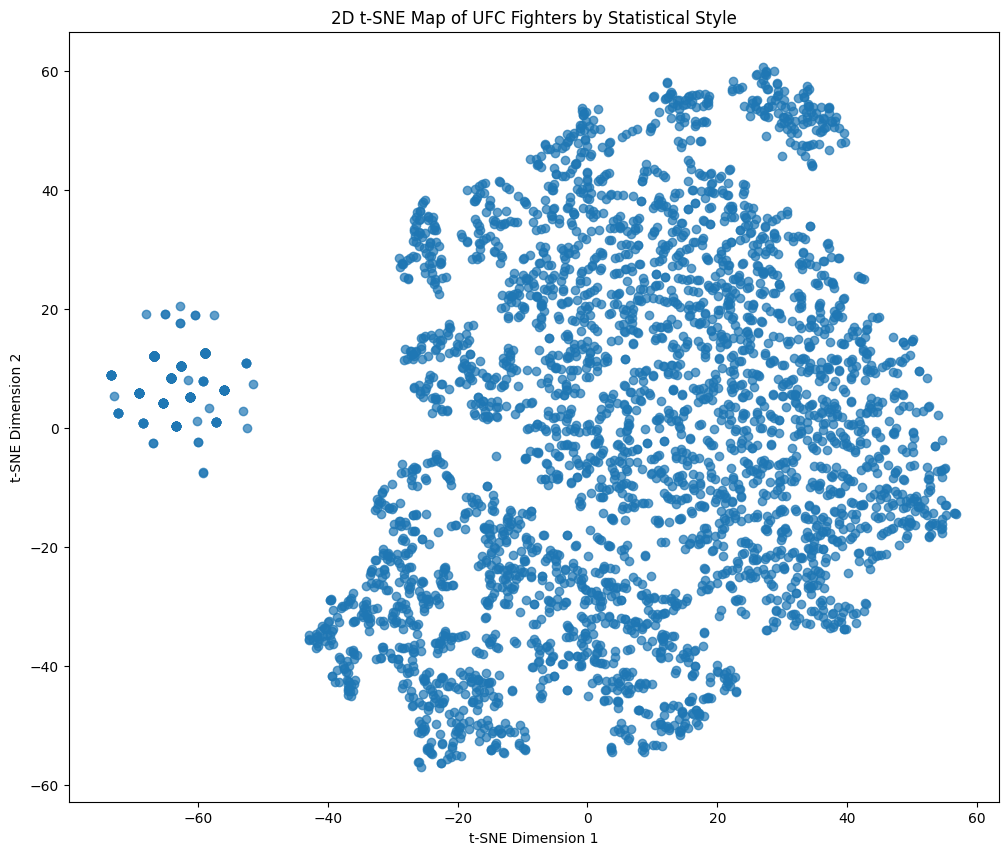

In [8]:

plt.figure(figsize=(12, 10))

plt.scatter(
    cluster_df["tsne_2d_x"],
    cluster_df["tsne_2d_y"],
    alpha=0.7,
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("2D t-SNE Map of UFC Fighters by Statistical Style")

plt.show()


## 2D Labeled Visualization

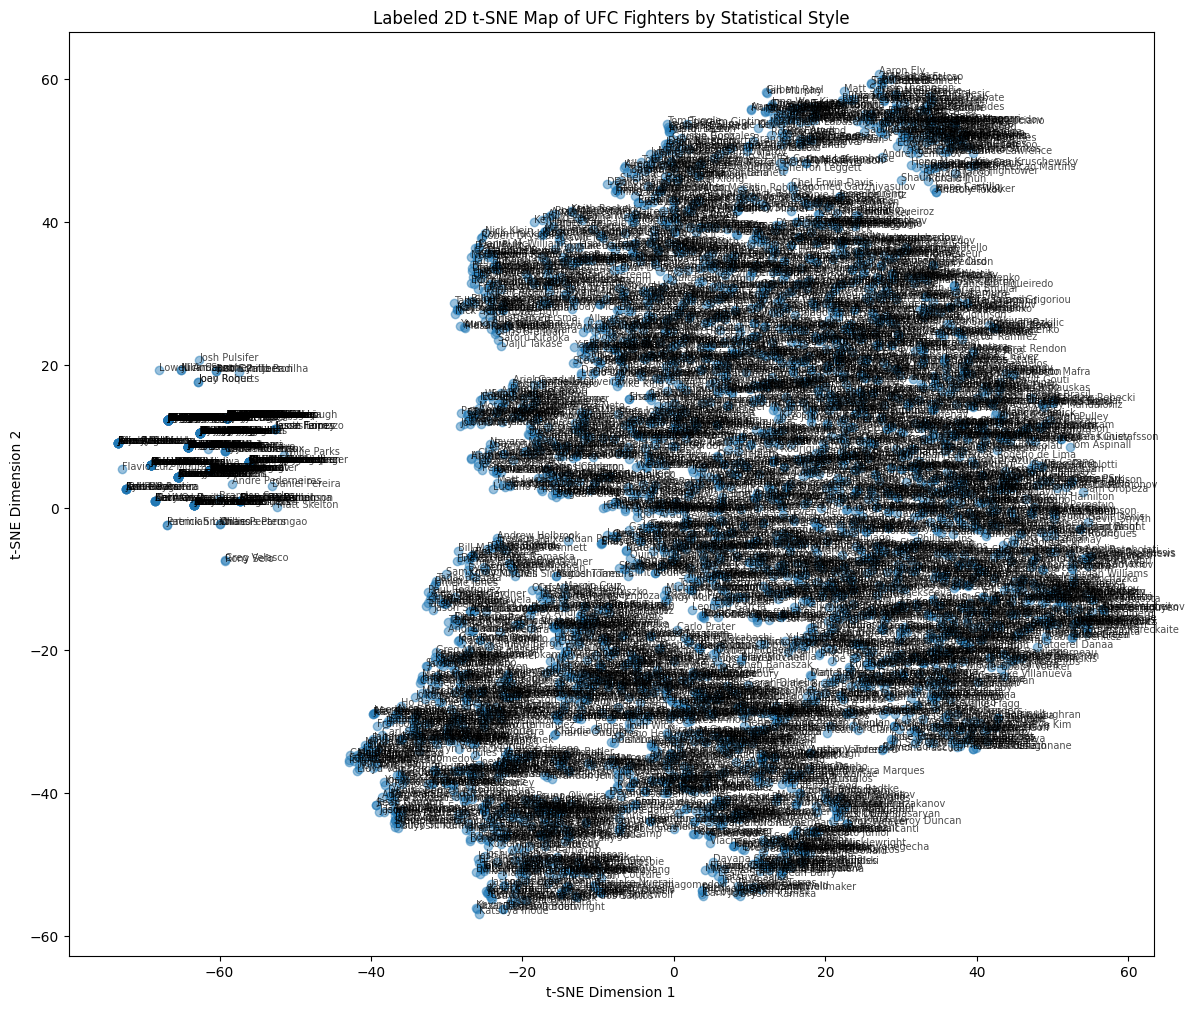

In [9]:

plt.figure(figsize=(14, 12))

plt.scatter(
    cluster_df["tsne_2d_x"],
    cluster_df["tsne_2d_y"],
    alpha=0.45,
)

for _, row in cluster_df.iterrows():
    plt.text(
        row["tsne_2d_x"],
        row["tsne_2d_y"],
        str(row[NAME_COLUMN]),
        fontsize=7,
        alpha=0.7,
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("Labeled 2D t-SNE Map of UFC Fighters by Statistical Style")

plt.show()



## 2D t-SNE Colored by a Statistic

Try changing `COLOR_COLUMN` to any one of the feature columns.


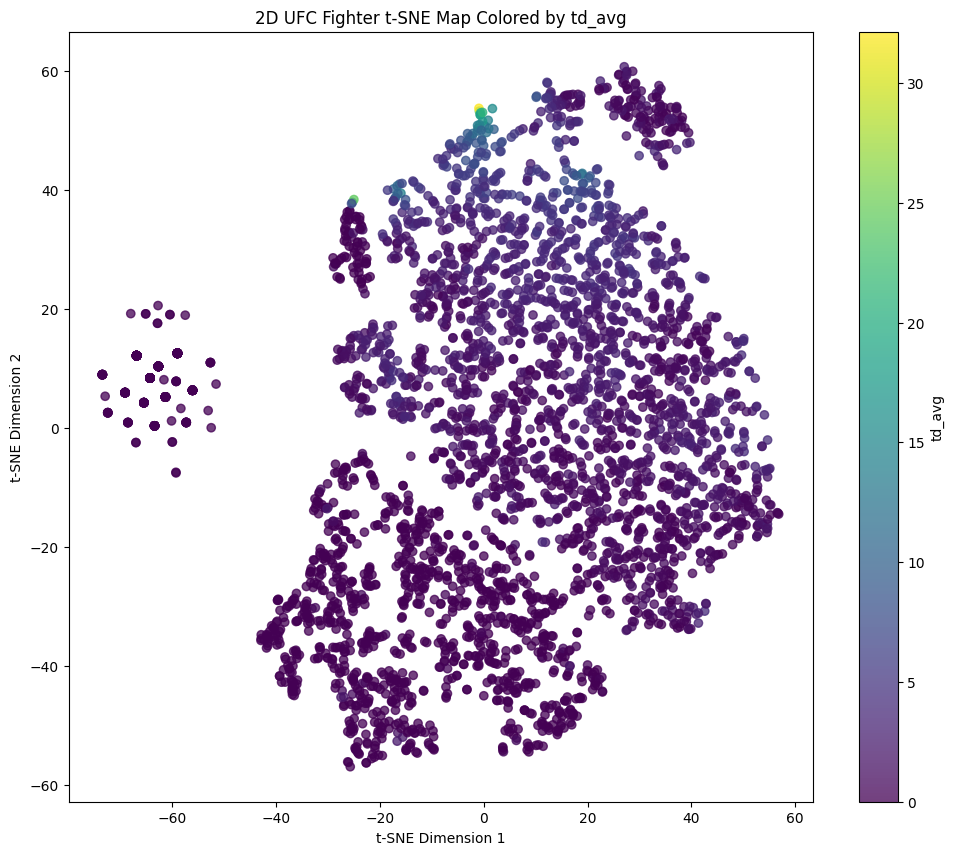

In [10]:

COLOR_COLUMN = "td_avg"

plt.figure(figsize=(12, 10))

scatter = plt.scatter(
    cluster_df["tsne_2d_x"],
    cluster_df["tsne_2d_y"],
    c=cluster_df[COLOR_COLUMN],
    alpha=0.75,
)

plt.colorbar(scatter, label=COLOR_COLUMN)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title(f"2D UFC Fighter t-SNE Map Colored by {COLOR_COLUMN}")

plt.show()



## Run 3D t-SNE

This recomputes t-SNE with `n_components=3`.

The 3D embedding is not just the 2D embedding with a third coordinate added; it is a separate optimization.


In [11]:

tsne_3d = TSNE(
    n_components=3,
    perplexity=adjusted_perplexity,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)

embedding_3d = tsne_3d.fit_transform(X_scaled)

cluster_df["tsne_3d_x"] = embedding_3d[:, 0]
cluster_df["tsne_3d_y"] = embedding_3d[:, 1]
cluster_df["tsne_3d_z"] = embedding_3d[:, 2]

cluster_df[[NAME_COLUMN, "tsne_3d_x", "tsne_3d_y", "tsne_3d_z"]].head()


,name,tsne_3d_x,tsne_3d_y,tsne_3d_z
0,Wuziazibieke Jiahefu,3.625785,12.278512,7.830421
1,Cristian Quinonez,8.771899,-4.618976,-8.284283
2,Gilbert Yvel,-6.360468,-5.169445,2.116193
3,Kennedy Nzechukwu,11.580036,-9.876359,-4.815780
4,Takahiro Oba,-10.477076,-2.859221,11.361320


## 3D t-SNE Visualization

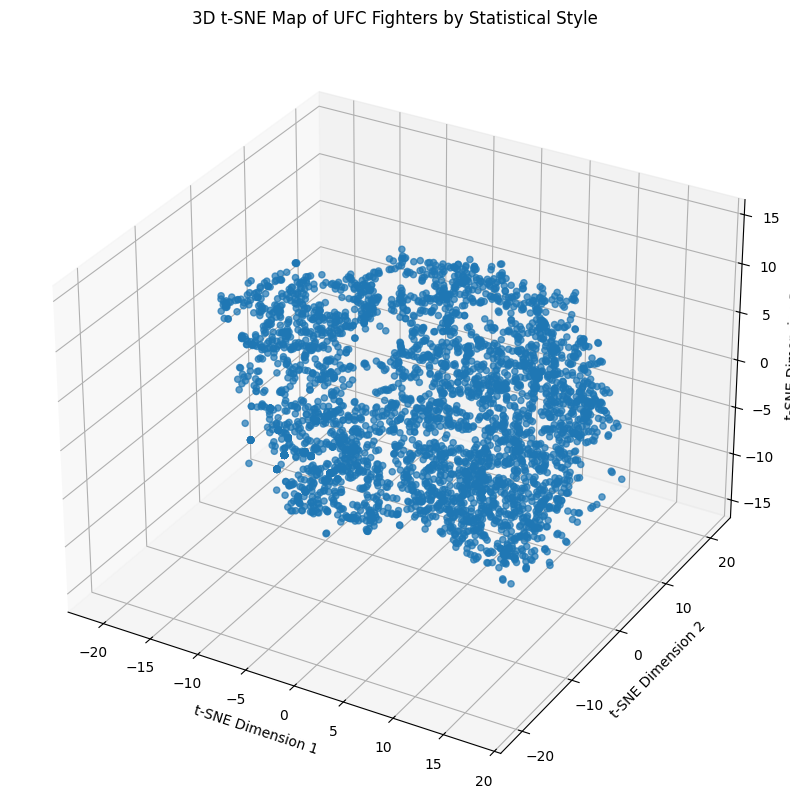

In [12]:

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    cluster_df["tsne_3d_x"],
    cluster_df["tsne_3d_y"],
    cluster_df["tsne_3d_z"],
    alpha=0.7,
)

ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.set_zlabel("t-SNE Dimension 3")
ax.set_title("3D t-SNE Map of UFC Fighters by Statistical Style")

plt.show()



## 3D t-SNE Colored by a Statistic

Change `COLOR_COLUMN` to highlight different fighter-style dimensions.


In [ ]:

COLOR_COLUMN = "td_avg"

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    cluster_df["tsne_3d_x"],
    cluster_df["tsne_3d_y"],
    cluster_df["tsne_3d_z"],
    c=cluster_df[COLOR_COLUMN],
    alpha=0.75,
)

fig.colorbar(scatter, ax=ax, label=COLOR_COLUMN, shrink=0.65)

ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.set_zlabel("t-SNE Dimension 3")
ax.set_title(f"3D UFC Fighter t-SNE Map Colored by {COLOR_COLUMN}")

plt.show()



## Optional Interactive 3D Plot with Plotly

This cell is optional. It gives a rotatable 3D plot.

If Plotly is not installed, uncomment the install line.


In [17]:

# If needed:
# %pip install plotly

try:
    import plotly.express as px
    import plotly.io as pio

    pio.renderers.default = "browser"

    fig = px.scatter_3d(
        cluster_df,
        x="tsne_3d_x",
        y="tsne_3d_y",
        z="tsne_3d_z",
        color=COLOR_COLUMN,
        hover_name=NAME_COLUMN,
        hover_data=FEATURE_COLUMNS,
        title=f"Interactive 3D t-SNE Map Colored by {COLOR_COLUMN}",
    )

    fig.show()

except ImportError:
    print("Plotly is not installed. Uncomment `%pip install plotly` above and rerun this cell.")



## Find Similar Fighters

This uses distance in the 2D t-SNE map. For more serious similarity search, use the standardized feature matrix instead.


In [18]:

def find_nearby_fighters_2d(fighter_name, n=10):
    matches = cluster_df[
        cluster_df[NAME_COLUMN].str.contains(fighter_name, case=False, na=False)
    ]

    if matches.empty:
        raise ValueError(f"No fighter found matching {fighter_name!r}")

    target = matches.iloc[0]

    distances = np.sqrt(
        (cluster_df["tsne_2d_x"] - target["tsne_2d_x"]) ** 2
        + (cluster_df["tsne_2d_y"] - target["tsne_2d_y"]) ** 2
    )

    result = cluster_df.copy()
    result["tsne_2d_distance"] = distances

    return (
        result
        .sort_values("tsne_2d_distance")
        [[NAME_COLUMN, "tsne_2d_distance", "tsne_2d_x", "tsne_2d_y"] + FEATURE_COLUMNS]
        .head(n + 1)
    )

def find_nearby_fighters_3d(fighter_name, n=10):
    matches = cluster_df[
        cluster_df[NAME_COLUMN].str.contains(fighter_name, case=False, na=False)
    ]

    if matches.empty:
        raise ValueError(f"No fighter found matching {fighter_name!r}")

    target = matches.iloc[0]

    distances = np.sqrt(
        (cluster_df["tsne_3d_x"] - target["tsne_3d_x"]) ** 2
        + (cluster_df["tsne_3d_y"] - target["tsne_3d_y"]) ** 2
        + (cluster_df["tsne_3d_z"] - target["tsne_3d_z"]) ** 2
    )

    result = cluster_df.copy()
    result["tsne_3d_distance"] = distances

    return (
        result
        .sort_values("tsne_3d_distance")
        [[NAME_COLUMN, "tsne_3d_distance", "tsne_3d_x", "tsne_3d_y", "tsne_3d_z"] + FEATURE_COLUMNS]
        .head(n + 1)
    )

# Examples:
# find_nearby_fighters_2d("Jon Jones", n=10)
# find_nearby_fighters_3d("Jon Jones", n=10)


In [20]:
find_nearby_fighters_3d("Jon Jones", n=10)

,name,tsne_3d_distance,tsne_3d_x,tsne_3d_y,tsne_3d_z,sig_str_land_pM,sig_str_land_pct,sig_str_abs_pM,sig_str_def_pct,td_avg,td_land_pct,td_def_pct,sub_avg
873,Jon Jones,0.000000,14.686365,6.754658,-1.129447,4.38,0.58,2.24,0.64,1.89,0.45,0.95,0.5
828,Matt Grice,0.958669,14.549497,5.913206,-0.690961,4.09,0.53,2.69,0.56,2.19,0.37,0.82,0.5
3425,Daniel Cormier,1.018154,14.236591,5.899350,-0.808840,4.25,0.52,2.92,0.54,1.83,0.44,0.80,0.4
2992,Kamaru Usman,1.165921,13.831009,6.805764,-0.338798,4.36,0.52,2.74,0.54,2.82,0.45,0.89,0.1
3238,Will Brooks,1.205418,13.843890,5.904977,-0.983461,4.26,0.59,2.54,0.56,2.08,0.51,0.82,0.3
2308,Amanda Nunes,1.426324,13.447898,7.260050,-0.634293,4.55,0.51,2.62,0.57,2.73,0.54,0.82,0.7
293,Ludovit Klein,1.445139,13.484036,6.001066,-1.403181,3.81,0.54,3.22,0.54,1.70,0.51,0.91,0.0
3565,Morgan Charriere,1.651795,13.057290,7.027642,-1.124907,3.87,0.51,3.74,0.57,2.47,0.57,0.83,0.6
3853,Beneil Dariush,1.661214,15.198011,5.228261,-0.719613,3.78,0.48,2.65,0.57,1.90,0.34,0.80,0.9
1246,Loma Lookboonmee,1.830480,13.493630,5.397938,-0.833898,4.10,0.57,2.48,0.53,1.90,0.50,0.72,0.1


## Explore Statistical Extremes

In [21]:

for col in FEATURE_COLUMNS:
    print()
    print("=" * 70)
    print(col)

    display(
        cluster_df[[NAME_COLUMN, col]]
        .sort_values(col, ascending=False)
        .head(10)
    )



sig_str_land_pM


,name,sig_str_land_pM
3713,Yuneisy Duben,20.55
2208,Rex Richards,17.65
2915,Tallison Teixeira,14.87
3711,Islam Dulatov,14.27
3371,JR Coughran,12.29
3370,Kim Couture,12.12
308,Ramazan Kuramagomedov,11.67
3489,Shannon Clark,11.51
808,Carli Judice,11.23
2304,Taiyilake Nueraji,11.01



sig_str_land_pct


,name,sig_str_land_pct
43,Min Soo Kim,1.0
836,Neiman Gracie,1.0
1403,Tatsuya Iwasaki,1.0
1614,Gian Siqueira,1.0
246,Rene Kronvold,1.0
3735,Derek Downey,1.0
3088,Victor Valenzuela,1.0
1696,Yuya Shirai,1.0
1544,Waachiim Spiritwolf,1.0
1045,David Gardner,1.0



sig_str_abs_pM


...

,name,td_land_pct
75,Collin Huckbody,1.0
12,Mando Gutierrez,1.0
3184,Abdul-Kerim Edilov,1.0
2165,Colin Robinson,1.0
907,Lyman Good,1.0
3919,Marius Enache,1.0
26,Solomon Hutcherson,1.0
926,Kyle Jensen,1.0
73,Mark Holst,1.0
3514,Murad Chunkaiev,1.0



td_def_pct


,name,td_def_pct
5,Mikheil Sazhiniani,1.0
1044,Shamil Gaziev,1.0
1049,Sean Gauci,1.0
962,Billy Ray Goff,1.0
970,Bubba Jenkins,1.0
1088,Patricky Freire,1.0
3813,Jose Delgado,1.0
3815,Wallen Del Rosario,1.0
3817,Rafael Del Real,1.0
3839,Philip De Fries,1.0



sub_avg


,name,sub_avg
284,Nick Klein,24.3
3707,Robert Drysdale,21.9
586,Daniel McWilliams,21.6
474,Dan Molina,20.9
2056,Paul Ruiz,20.9
75,Collin Huckbody,20.4
1446,Gerald Strebendt,16.4
105,Isaiah Hill,14.5
1736,Kenneth Seegrist,14.4
361,Will Kerr,14.3



## Save the Clustered Dataset

This saves both the 2D and 3D t-SNE coordinates.


In [22]:

DATA_DIR.mkdir(exist_ok=True)

cluster_df.to_csv(OUTPUT_CLUSTERED_CSV_PATH, index=False)

with sqlite3.connect(OUTPUT_SQLITE_PATH) as conn:
    cluster_df.to_sql("fighters_tsne_2d_3d", conn, if_exists="replace", index=False)

print(f"Saved clustered CSV to {OUTPUT_CLUSTERED_CSV_PATH}")
print(f"Saved clustered SQLite database to {OUTPUT_SQLITE_PATH}")


Saved clustered CSV to data/ufc_fighters_complete_stats_with_tsne_2d_3d.csv
Saved clustered SQLite database to data/ufc_fighters_tsne_2d_3d.sqlite



## Notes for Interpretation

t-SNE is good for local neighborhoods: fighters near each other often have similar statistical profiles.

The axes themselves do not have direct statistical meaning.

The 2D and 3D embeddings are different optimization problems, so do not expect the 3D coordinates to be a simple extension of the 2D map.
